# Day 7/60 — Stateless Architecture & Multi-Data-Center

## System Design Series

**Topic:** Move session state out of web servers into a shared store — then spread the entire stack across multiple geographic data centers for global scale.

**What we cover:**
- Stateful architecture: sticky sessions, why they break at scale
- Stateless architecture: shared state store, any server handles any user
- Stateful vs Stateless comparison (attribute table + radar chart)
- Autoscaling: how stateless enables true elastic scaling
- Multi-data-center: GeoDNS routing, two-DC layout, cross-DC DB replication
- Multi-DC: latency impact, failover sequence, operational challenges
- Architecture evolution and Day 7 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE    = '#4C72B0'
C_GREEN   = '#27AE60'
C_ORANGE  = '#DD8452'
C_RED     = '#C44E52'
C_TEAL    = '#2E86AB'
C_GRAY    = '#F8F9FA'
C_LB      = '#E67E22'
C_DB      = '#8E44AD'
C_SERVER  = '#4C72B0'   # blue   — web/app server
C_SESSION = '#E74C3C'   # red    — session data (stateful, problem)
C_SHARED  = '#27AE60'   # green  — shared data store (stateless, solution)
C_USER    = '#2E86AB'   # teal   — end user
C_DC1     = '#2980B9'   # blue   — data center 1
C_DC2     = '#8E44AD'   # purple — data center 2

print("Libraries loaded. Day 7 ready.")


Libraries loaded. Day 7 ready.


### What this does

Loads Matplotlib and NumPy, and defines the Day 7 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_SESSION` | Red | Session data pinned to server (the problem) |
| `C_SHARED` | Green | Shared state store (the solution) |
| `C_SERVER` | Blue | Web/App server |
| `C_USER` | Teal | End user |
| `C_DC1` | Blue | Data Center 1 (US) |
| `C_DC2` | Purple | Data Center 2 (Asia) |

Red = problem (stateful coupling), Green = solution (stateless freedom).

## 2. Stateful Architecture

In a stateful server, each server holds session data **in its own memory**. When User A logs in via Server 1, that session is stored only on Server 1.

**The consequence:** The load balancer must use **sticky sessions** — a mechanism that pins each user to one specific server for all future requests. If that server goes down, the session is lost and the user must re-authenticate.

**The three problems with sticky sessions:**
1. **Scaling is hard** — you can't freely remove a server while users are pinned to it
2. **Load imbalance** — some servers get pinned with heavy users while others are idle
3. **Failure = session loss** — crash the server, lose every user's session on it

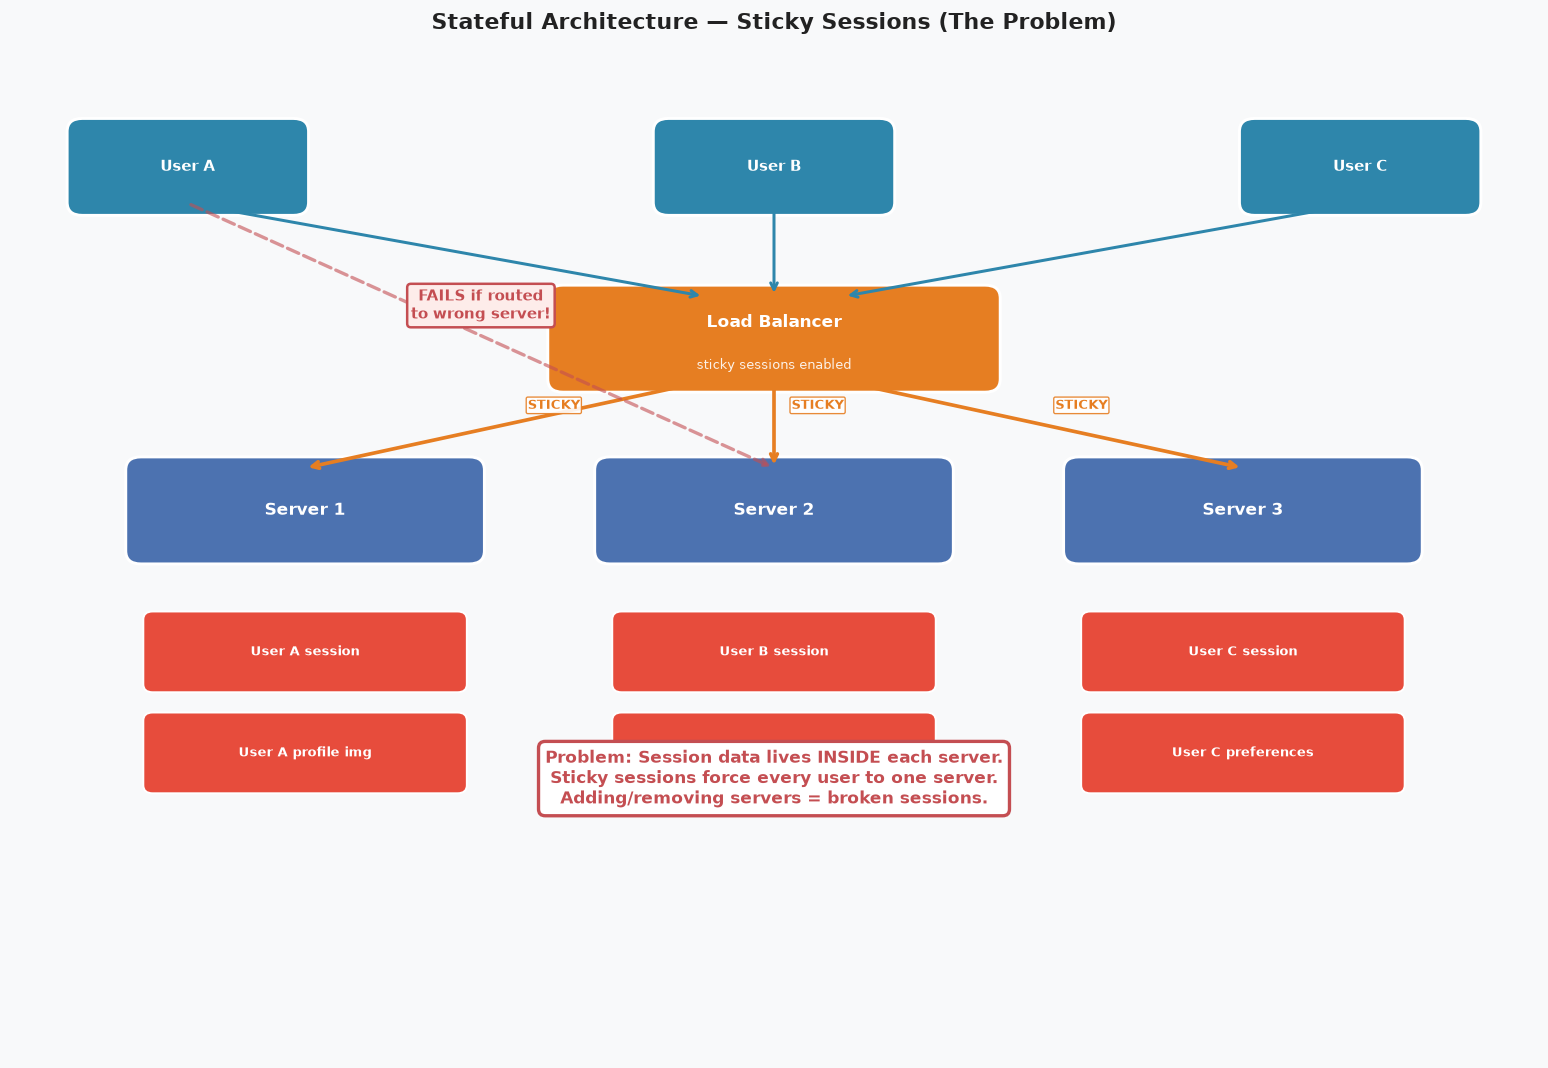

Stateful diagram done.


In [2]:
# Stateful architecture: sticky sessions, session data pinned to each server

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

def box(ax, x, y, w, h, label, color, sub='', fs=9.5):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.18
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.9))

# ── Users ─────────────────────────────────────────────────────────────────────
users = [('User A', 1.5), ('User B', 6.5), ('User C', 11.5)]
for name, ux in users:
    box(ax, ux, 8.8, 1.8, 0.7, name, C_USER, fs=9)

# ── Load Balancer ─────────────────────────────────────────────────────────────
box(ax, 6.5, 7.1, 3.6, 0.8, 'Load Balancer', C_LB,
    sub='sticky sessions enabled', fs=10)

# User -> LB arrows
for ux in [1.5, 6.5, 11.5]:
    arr(ax, ux, 8.44, 6.5 + (ux-6.5)*0.12, 7.52, '', C_USER, lw=1.8)

# ── Web Servers ───────────────────────────────────────────────────────────────
server_xs = [2.5, 6.5, 10.5]
server_names = ['Server 1', 'Server 2', 'Server 3']
for sx, sname in zip(server_xs, server_names):
    box(ax, sx, 5.4, 2.8, 0.8, sname, C_SERVER, fs=10)

# LB -> servers (sticky: User A always -> Server 1, etc.)
sticky_pairs = [(1.5, 2.5), (6.5, 6.5), (11.5, 10.5)]
for ux, sx in sticky_pairs:
    arr(ax, 6.5 + (ux-6.5)*0.1, 6.7, sx, 5.82, 'STICKY', C_LB, lw=2.2)

# ── Session data blocks pinned to each server ─────────────────────────────────
session_labels = [
    ['User A session', 'User A profile img'],
    ['User B session', 'User B cart data'],
    ['User C session', 'User C preferences'],
]
for sx, labels in zip(server_xs, session_labels):
    for j, lbl in enumerate(labels):
        ry = 4.0 - j * 1.0
        r = FancyBboxPatch((sx - 1.3, ry - 0.32), 2.6, 0.64,
                           boxstyle='round,pad=0.08',
                           facecolor=C_SESSION, edgecolor='white', lw=1.2)
        ax.add_patch(r)
        ax.text(sx, ry, lbl, ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

# ── Problem annotation ────────────────────────────────────────────────────────
# Crossed-out arrow: User A trying to go to Server 2
ax.annotate('', xy=(6.5, 5.82), xytext=(1.5, 8.44),
            arrowprops=dict(arrowstyle='->', color=C_RED, lw=2.0,
                            linestyle='dashed', alpha=0.6))
ax.text(4.0, 7.3, 'FAILS if routed\nto wrong server!',
        ha='center', fontsize=9, color=C_RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#FDECEA',
                  edgecolor=C_RED, lw=1.5))

# ── Session data label ────────────────────────────────────────────────────────
ax.text(6.5, 2.5,
        'Problem: Session data lives INSIDE each server.\n'
        'Sticky sessions force every user to one server.\n'
        'Adding/removing servers = broken sessions.',
        ha='center', fontsize=10, color=C_RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_RED, lw=2.0))

ax.set_title('Stateful Architecture — Sticky Sessions (The Problem)',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_stateful.png', dpi=130, bbox_inches='tight')
plt.show()
print("Stateful diagram done.")


### What this shows

Three users, three servers, with session data (red blocks) physically stored inside each server.

**Solid arrows:** The correct sticky routing — User A always to Server 1, B to Server 2, C to Server 3.  
**Dashed red arrow:** User A's request accidentally reaching Server 2 — authentication fails because Server 2 has no knowledge of User A's session.

The red session data blocks represent the coupling: each server has become stateful, meaning it is no longer interchangeable with the others. This is the architectural anti-pattern that prevents horizontal scaling.

## 3. Stateless Architecture

The fix is simple in concept: **move the session data out of the servers and into a shared store**.

With a shared state store (Redis, DynamoDB, Memcached):
- Every server can read and write any user's session
- The load balancer has no special routing requirements — round-robin works perfectly
- Adding a new server is instant — it immediately has access to all sessions
- Removing a server is safe — sessions survive in the shared store

> **NoSQL is preferred** for the state store because it scales horizontally, handles simple key-value session lookups efficiently, and can be clustered across data centers.

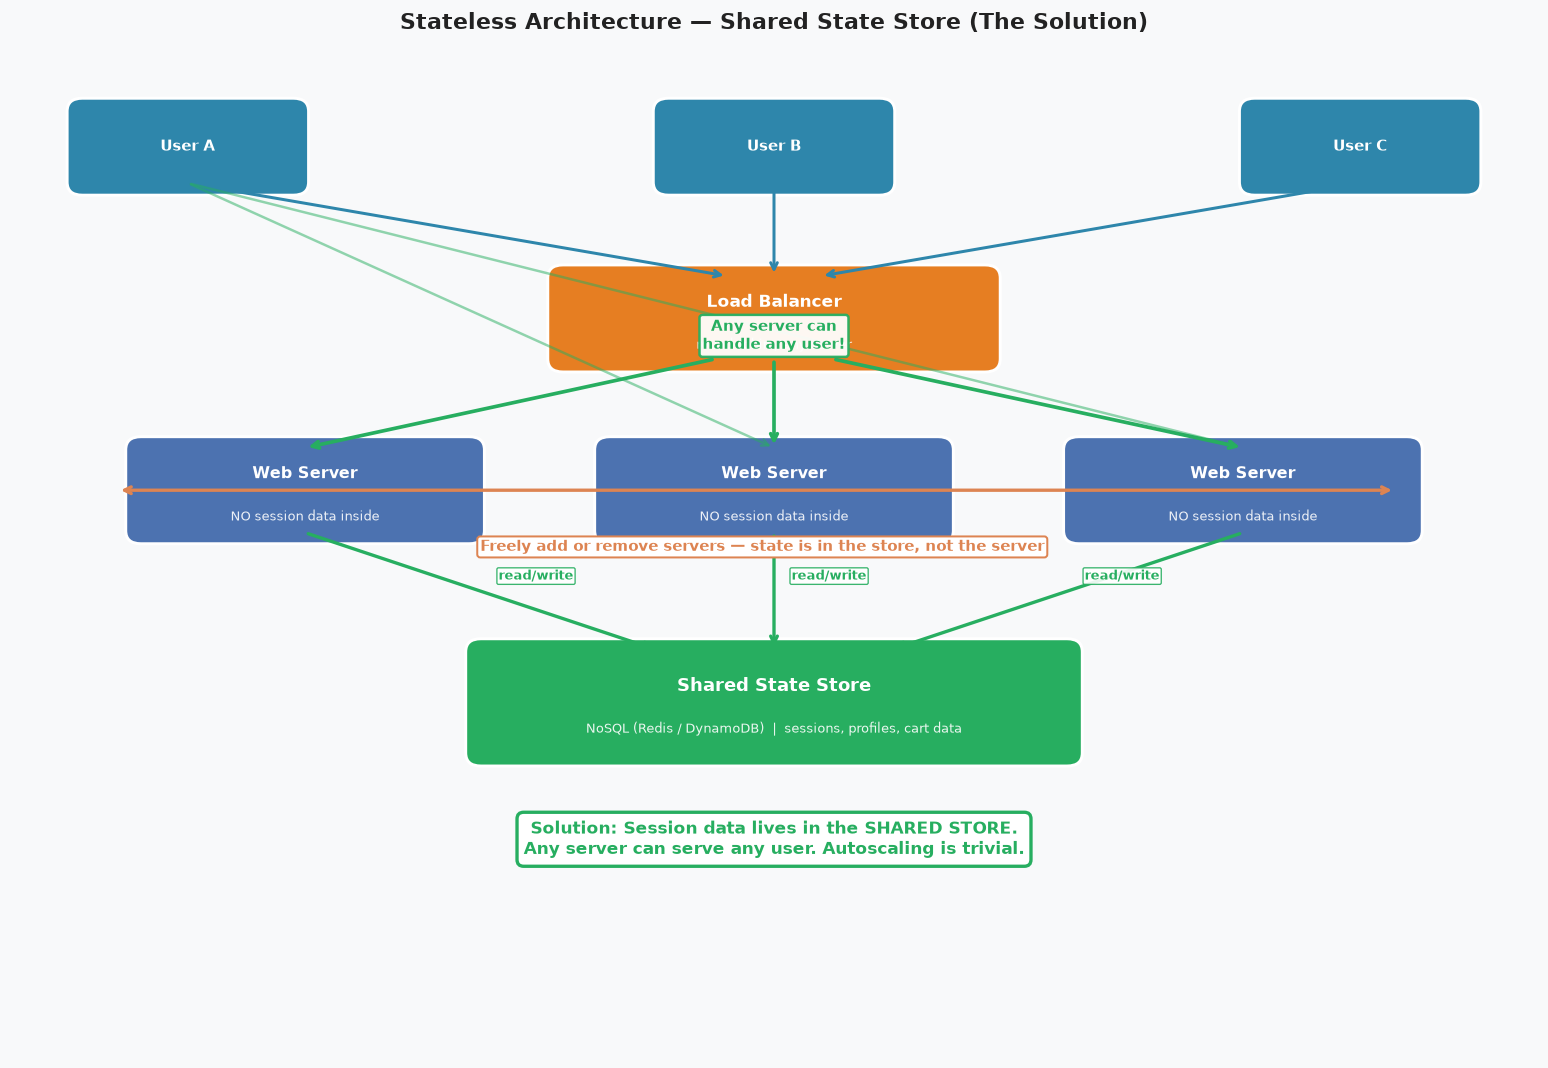

Stateless diagram done.


In [3]:
# Stateless architecture: shared data store, any server can handle any user

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

def box(ax, x, y, w, h, label, color, sub='', fs=9.5):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.15
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.9))

# ── Users ─────────────────────────────────────────────────────────────────────
for name, ux in [('User A', 1.5), ('User B', 6.5), ('User C', 11.5)]:
    box(ax, ux, 9.0, 1.8, 0.7, name, C_USER, fs=9)

# ── Load Balancer ─────────────────────────────────────────────────────────────
box(ax, 6.5, 7.3, 3.6, 0.8, 'Load Balancer', C_LB,
    sub='round-robin / any server', fs=10)
for ux in [1.5, 6.5, 11.5]:
    arr(ax, ux, 8.64, 6.5 + (ux-6.5)*0.08, 7.72, '', C_USER, lw=1.8)

# ── Web Servers (stateless — no session data inside) ─────────────────────────
server_xs = [2.5, 6.5, 10.5]
for sx in server_xs:
    box(ax, sx, 5.6, 2.8, 0.8, 'Web Server', C_SERVER,
        sub='NO session data inside', fs=9.5)

# LB -> all servers (any combination OK)
for ux, sx in [(1.5, 2.5), (6.5, 6.5), (11.5, 10.5)]:
    arr(ax, 6.5 + (ux-6.5)*0.1, 6.9, sx, 6.02, '', C_GREEN, lw=2.2)

# Cross-connections: User A's request can go to Server 2 or 3 too
for sx in [6.5, 10.5]:
    ax.annotate('', xy=(sx, 6.02), xytext=(1.5, 8.64),
                arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.5,
                                alpha=0.5))
ax.text(6.5, 7.0, 'Any server can\nhandle any user!',
        ha='center', fontsize=9, color=C_GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=C_GREEN, lw=1.5, alpha=0.95))

# ── Shared State Store ────────────────────────────────────────────────────────
box(ax, 6.5, 3.5, 5.0, 1.0, 'Shared State Store', C_SHARED,
    sub='NoSQL (Redis / DynamoDB)  |  sessions, profiles, cart data', fs=11)

# Server -> shared store (read/write)
for sx in server_xs:
    arr(ax, sx, 5.18, 6.5 + (sx-6.5)*0.25, 4.02, 'read/write', C_SHARED, lw=2.0)

# ── Auto-scale bracket ────────────────────────────────────────────────────────
ax.annotate('', xy=(11.8, 5.6), xytext=(0.9, 5.6),
            arrowprops=dict(arrowstyle='<->', color=C_ORANGE, lw=2.0))
ax.text(6.4, 5.0, 'Freely add or remove servers — state is in the store, not the server',
        ha='center', fontsize=9, color=C_ORANGE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.2))

# ── Solution note ─────────────────────────────────────────────────────────────
ax.text(6.5, 2.0,
        'Solution: Session data lives in the SHARED STORE.\n'
        'Any server can serve any user. Autoscaling is trivial.',
        ha='center', fontsize=10, color=C_GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_GREEN, lw=2.0))

ax.set_title('Stateless Architecture — Shared State Store (The Solution)',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_stateless.png', dpi=130, bbox_inches='tight')
plt.show()
print("Stateless diagram done.")


### What this shows

The same three servers, but now the session data blocks are **gone from the servers**. The servers are now identical, stateless nodes — they hold no user-specific data.

**Green arrows** from all users: any request can go to any server — the cross-connections (User A to Server 2 or Server 3) are now valid and correct.  
**Green arrows to shared store:** every server reads and writes session data through the shared store.

**Orange double-headed arrow:** The autoscale boundary — servers can be freely added or removed because removing Server 3 doesn't affect any user's session. This is the unlock that makes elastic auto-scaling possible.

## 4. Stateful vs Stateless: Full Comparison

The architectural choice between stateful and stateless affects every aspect of system design — from how you handle failures to how much you pay for compute.

**When stateful might be acceptable:**
- Single-server applications with no scaling requirement
- Embedded/IoT systems where a shared store is impractical
- Legacy systems where refactoring is too costly

**When stateless is required:**
- Any system behind a load balancer
- Any system that auto-scales
- Any system that must survive server failures without user disruption

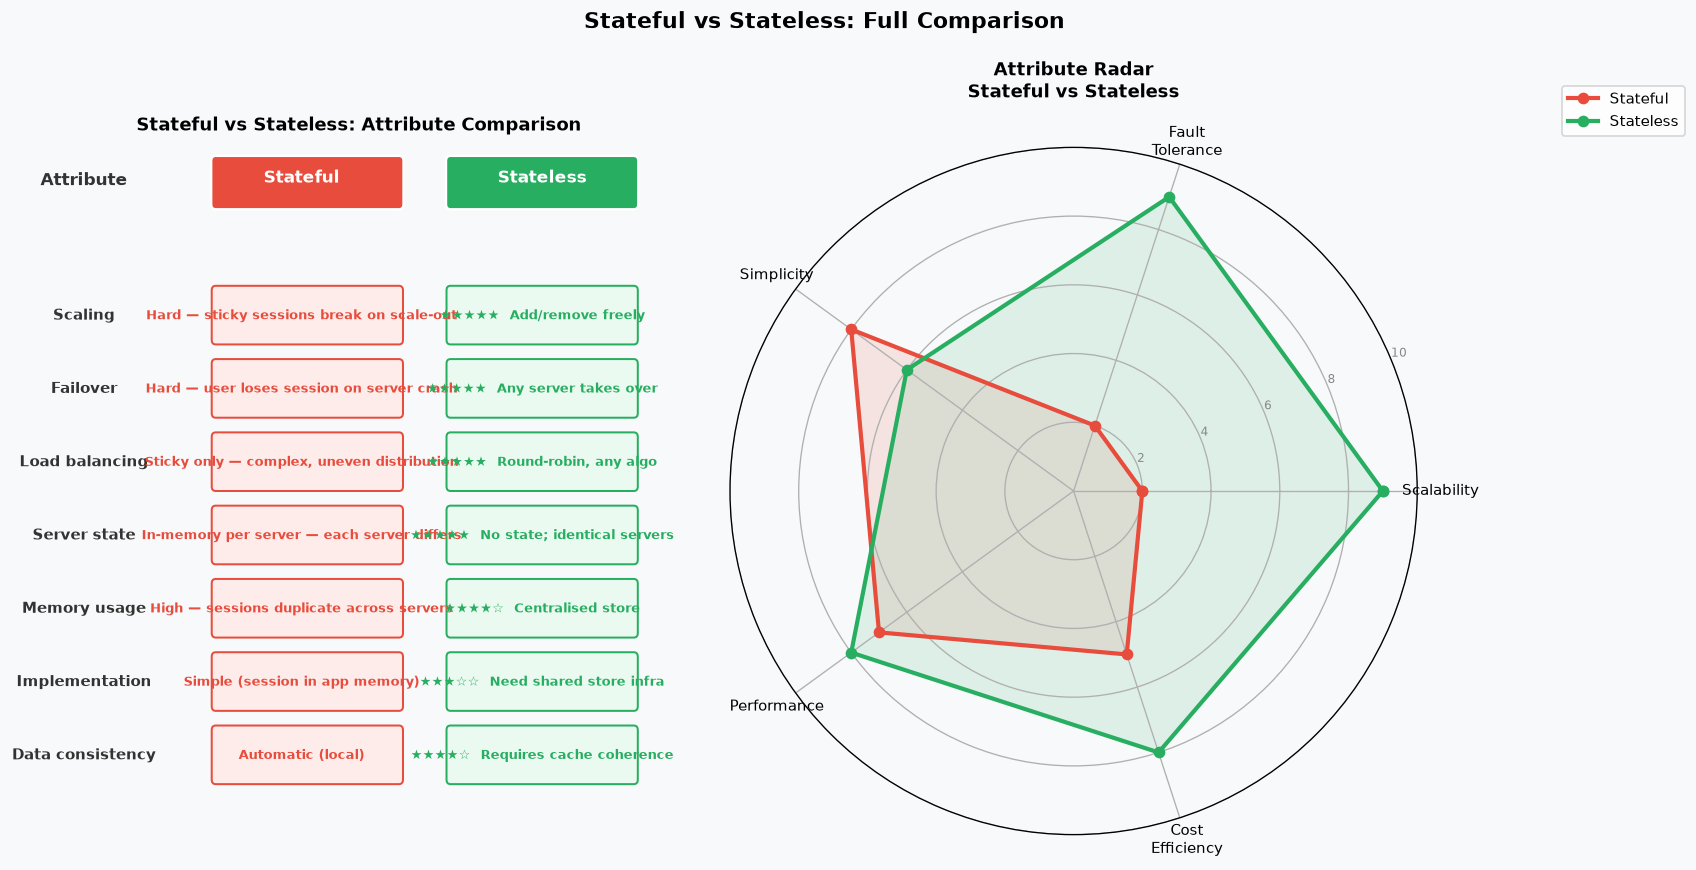

In [4]:
# Side-by-side comparison: stateful vs stateless on key attributes

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: attribute comparison table ─────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 12); ax.set_ylim(0, 11)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Stateful vs Stateless: Attribute Comparison',
             fontsize=11, fontweight='bold')

headers = ['Attribute', 'Stateful', 'Stateless']
col_x   = [1.2, 5.0, 9.2]

# Header row
ax.text(col_x[0], 10.3, headers[0], ha='center', fontsize=10,
        fontweight='bold', color='#333')
r1 = FancyBboxPatch((3.5, 10.0), 3.2, 0.68, boxstyle='round,pad=0.08',
                    facecolor=C_SESSION, edgecolor='white', lw=1.5)
ax.add_patch(r1)
ax.text(col_x[1], 10.34, headers[1], ha='center', fontsize=10,
        fontweight='bold', color='white')
r2 = FancyBboxPatch((7.6, 10.0), 3.2, 0.68, boxstyle='round,pad=0.08',
                    facecolor=C_SHARED, edgecolor='white', lw=1.5)
ax.add_patch(r2)
ax.text(col_x[2], 10.34, headers[2], ha='center', fontsize=10,
        fontweight='bold', color='white')

rows = [
    ('Scaling',         'Hard — sticky sessions break on scale-out', '★★★★★  Add/remove freely'),
    ('Failover',        'Hard — user loses session on server crash', '★★★★★  Any server takes over'),
    ('Load balancing',  'Sticky only — complex, uneven distribution', '★★★★★  Round-robin, any algo'),
    ('Server state',    'In-memory per server — each server differs', '★★★★★  No state; identical servers'),
    ('Memory usage',    'High — sessions duplicate across servers', '★★★★☆  Centralised store'),
    ('Implementation',  'Simple (session in app memory)', '★★★☆☆  Need shared store infra'),
    ('Data consistency','Automatic (local)', '★★★★☆  Requires cache coherence'),
]

y0 = 9.4
for attr, stateful_val, stateless_val in rows:
    y0 -= 1.15
    # Attribute
    ax.text(col_x[0], y0, attr, ha='center', va='center',
            fontsize=9, fontweight='bold', color='#333')
    # Stateful value
    r = FancyBboxPatch((3.5, y0 - 0.38), 3.2, 0.78,
                       boxstyle='round,pad=0.07',
                       facecolor='#FDECEA', edgecolor=C_SESSION, lw=1.2)
    ax.add_patch(r)
    ax.text(col_x[1], y0, stateful_val, ha='center', va='center',
            fontsize=7.5, color=C_SESSION, fontweight='bold')
    # Stateless value
    r = FancyBboxPatch((7.6, y0 - 0.38), 3.2, 0.78,
                       boxstyle='round,pad=0.07',
                       facecolor='#EAFAF1', edgecolor=C_SHARED, lw=1.2)
    ax.add_patch(r)
    ax.text(col_x[2], y0, stateless_val, ha='center', va='center',
            fontsize=7.5, color=C_SHARED, fontweight='bold')

# ── Right: radar / spider chart ───────────────────────────────────────────────
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2, polar=True)
ax2.set_facecolor(C_GRAY)

dims   = ['Scalability', 'Fault\nTolerance', 'Simplicity', 'Performance', 'Cost\nEfficiency']
statefull_scores   = [2, 2, 8, 7, 5]
stateless_scores   = [9, 9, 6, 8, 8]

N = len(dims)
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

for scores, color, label in [
    (statefull_scores, C_SESSION, 'Stateful'),
    (stateless_scores, C_SHARED,  'Stateless'),
]:
    vals = scores + scores[:1]
    ax2.plot(angles, vals, 'o-', lw=2.5, color=color, label=label)
    ax2.fill(angles, vals, alpha=0.12, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(dims, fontsize=9)
ax2.set_ylim(0, 10)
ax2.set_yticks([2, 4, 6, 8, 10])
ax2.set_yticklabels(['2','4','6','8','10'], fontsize=7, color='#888')
ax2.set_title('Attribute Radar\nStateful vs Stateless',
              fontsize=11, fontweight='bold', pad=16)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

plt.suptitle('Stateful vs Stateless: Full Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Attribute table:**  
Seven key attributes compared side by side. Red cells (stateful) show the friction: hard scaling, hard failover, complex load balancing. Green cells (stateless) show the freedom: 5-star scaling, any-server failover, all load-balancing algorithms work.

**Right — Radar chart:**  
Stateless (green) dominates on Scalability and Fault Tolerance — the two most important attributes at scale. Stateful (red) scores slightly higher on Simplicity because it requires no external shared store. The trade-off is worth it for almost every production system.

## 5. Autoscaling with Stateless Servers

The business case for stateless architecture is clearest in the context of autoscaling:

- **Stateful system:** To scale down (reduce cost during off-peak hours), you must first drain or migrate all active sessions from the server being removed. This is complex, slow, and often just avoided — the server stays running even when idle.
- **Stateless system:** Any server can be terminated instantly. The next request from that user hits any other server and retrieves the session from the shared store.

The cost impact compounds over time: stateful systems maintain a minimum floor of servers to avoid breaking pinned sessions, even at 3am when traffic is near zero.

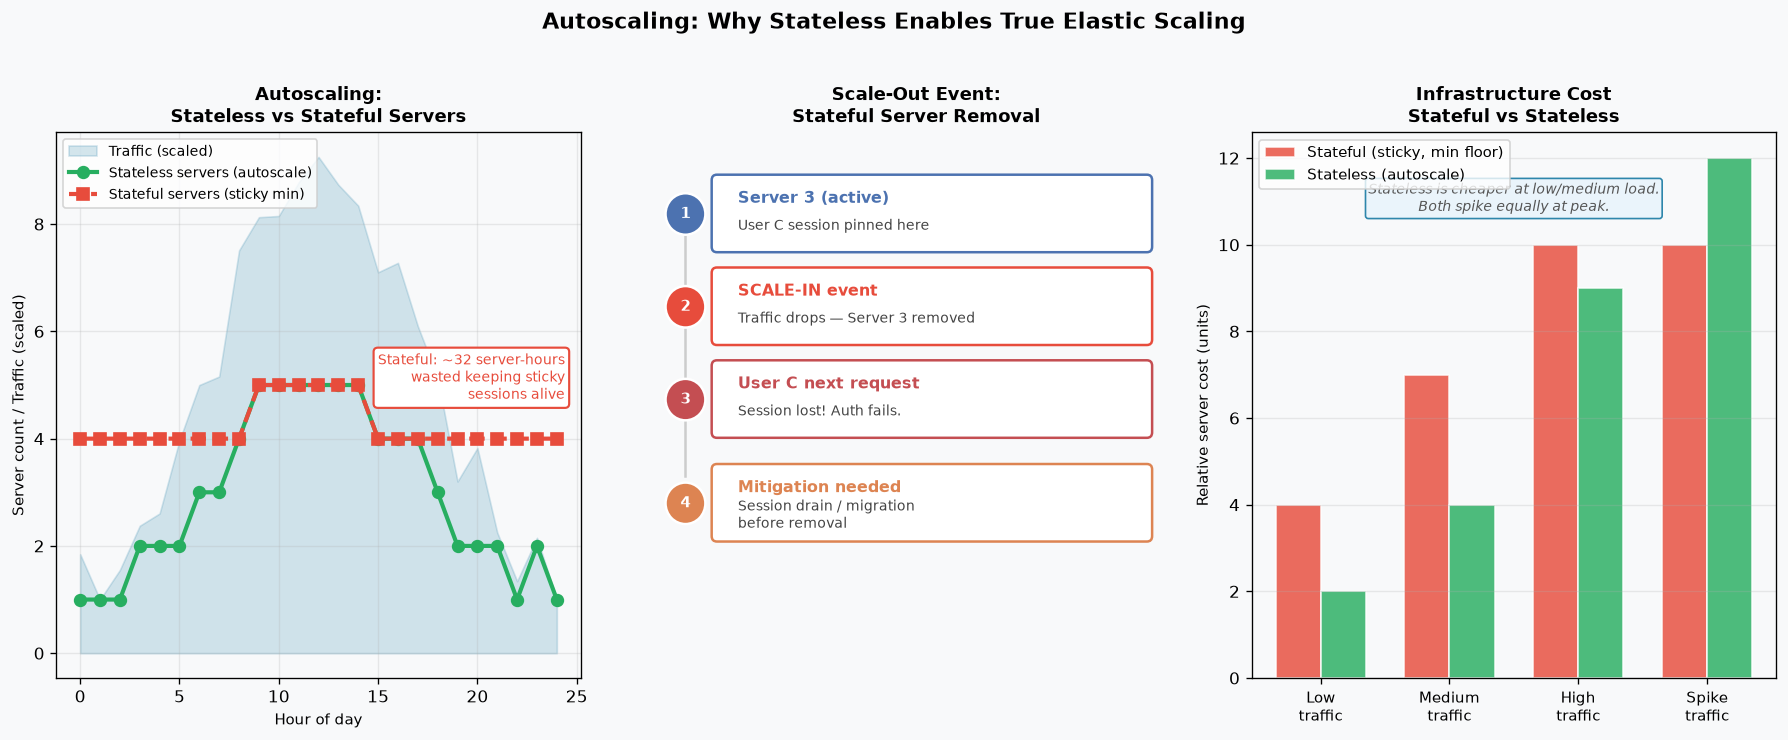

In [5]:
# Autoscaling: how stateless web tier enables dynamic server count

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C_GRAY)

np.random.seed(7)

# ── Left: traffic load vs server count over time ──────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)

hours = np.arange(0, 25)
traffic = (50 + 40 * np.sin((hours - 6) * np.pi / 12) +
           np.random.normal(0, 5, 25)).clip(10, 120)
# Stateless: servers scale with traffic
servers_stateless = np.ceil(traffic / 20).astype(int)
# Stateful: must keep min servers because sessions are pinned
servers_stateful  = np.maximum(servers_stateless, 4)   # can't drop below 4 (sessions still active)

ax.fill_between(hours, 0, traffic / 10, alpha=0.2, color=C_TEAL, label='Traffic (scaled)')
ax.plot(hours, servers_stateless, 'o-', color=C_SHARED,  lw=2.5, ms=7,
        label='Stateless servers (autoscale)')
ax.plot(hours, servers_stateful,  's--', color=C_SESSION, lw=2.5, ms=7,
        label='Stateful servers (sticky min)')

ax.set_xlabel('Hour of day', fontsize=9)
ax.set_ylabel('Server count / Traffic (scaled)', fontsize=9)
ax.set_title('Autoscaling:\nStateless vs Stateful Servers', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(alpha=0.25)

wasted = (servers_stateful - servers_stateless).sum()
ax.text(0.97, 0.55,
        f'Stateful: ~{wasted} server-hours\nwasted keeping sticky\nsessions alive',
        ha='right', va='center', transform=ax.transAxes, fontsize=8.5,
        color=C_SESSION,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=C_SESSION, lw=1.3))

# ── Middle: scale-out event — stateful failure scenario ───────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Scale-Out Event:\nStateful Server Removal', fontsize=11, fontweight='bold')

events = [
    (C_SERVER,  'Server 3 (active)',   'User C session pinned here', True),
    (C_SESSION, 'SCALE-IN event',      'Traffic drops — Server 3 removed', False),
    (C_RED,     'User C next request', 'Session lost! Auth fails.', False),
    (C_ORANGE,  'Mitigation needed',   'Session drain / migration\nbefore removal', False),
]
y_vals = [8.5, 6.8, 5.1, 3.2]
for i, ((color, title, body, _), y) in enumerate(zip(events, y_vals)):
    circ = plt.Circle((0.6, y), 0.38, facecolor=color,
                       edgecolor='white', lw=1.5, zorder=5)
    ax.add_patch(circ)
    ax.text(0.6, y, str(i+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=6)
    r = FancyBboxPatch((1.2, y - 0.6), 8.2, 1.22,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(1.6, y + 0.28, title, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(1.6, y - 0.22, body, ha='left', va='center',
            fontsize=8.5, color='#444')
    if i < 3:
        ax.plot([0.6, 0.6], [y - 0.4, y - 1.4], color='#CCC', lw=1.5, zorder=0)

# ── Right: cost comparison — stateful overhead ─────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)

scenarios = ['Low\ntraffic', 'Medium\ntraffic', 'High\ntraffic', 'Spike\ntraffic']
cost_stateful   = [4, 7, 10, 10]   # can't scale down fast; keeps min servers
cost_stateless  = [2, 4,  9, 12]   # can burst but also shrink

x = np.arange(len(scenarios)); w = 0.35
ax.bar(x - w/2, cost_stateful,  width=w, color=C_SESSION, alpha=0.82,
       edgecolor='white', label='Stateful (sticky, min floor)')
ax.bar(x + w/2, cost_stateless, width=w, color=C_SHARED,  alpha=0.82,
       edgecolor='white', label='Stateless (autoscale)')

ax.set_xticks(x); ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('Relative server cost (units)', fontsize=9)
ax.set_title('Infrastructure Cost\nStateful vs Stateless', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)

ax.text(0.5, 0.91,
        'Stateless is cheaper at low/medium load.\nBoth spike equally at peak.',
        ha='center', va='top', transform=ax.transAxes, fontsize=8.5,
        fontstyle='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.0))

plt.suptitle('Autoscaling: Why Stateless Enables True Elastic Scaling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_autoscaling.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Autoscaling over 24 hours:**  
Traffic follows a natural diurnal pattern (high midday, low overnight). Stateless servers (green) track traffic closely — they scale down aggressively at night. Stateful servers (red dashed) cannot drop below a minimum floor because active sessions are still pinned. The gap between the lines is wasted compute cost.

**Middle — Scale-in event failure sequence:**  
The 4-step chain shows what happens when a stateful server is removed mid-session. Step 3 is the critical failure: the user's next request hits a server that has no record of their session. Step 4 shows the mitigation: session drain (waiting for all sessions to expire or migrate before terminating the server).

**Right — Infrastructure cost comparison:**  
At low and medium traffic, stateless is meaningfully cheaper due to the ability to scale down. At peak/spike traffic both approaches cost about the same — the difference is on the downslope.

## 6. Multi-Data-Center Architecture

Once your system is stateless and horizontally scalable, the next global-scale challenge is **geographic latency and availability**.

A single data center (even at cloud scale) introduces latency for users far away. A user in Singapore connecting to a US-East origin faces 175-200 ms round-trip — noticeable for interactive applications.

**The solution:** Run the entire stack (web servers, cache, databases) in multiple regions:

- **GeoDNS:** Resolves your domain to the IP of the nearest data center based on the user's IP
- **Cross-DC DB replication:** Primary DB in one DC replicates asynchronously to replicas in others
- **Failover:** If one DC goes down, GeoDNS redirects all traffic to the surviving DC

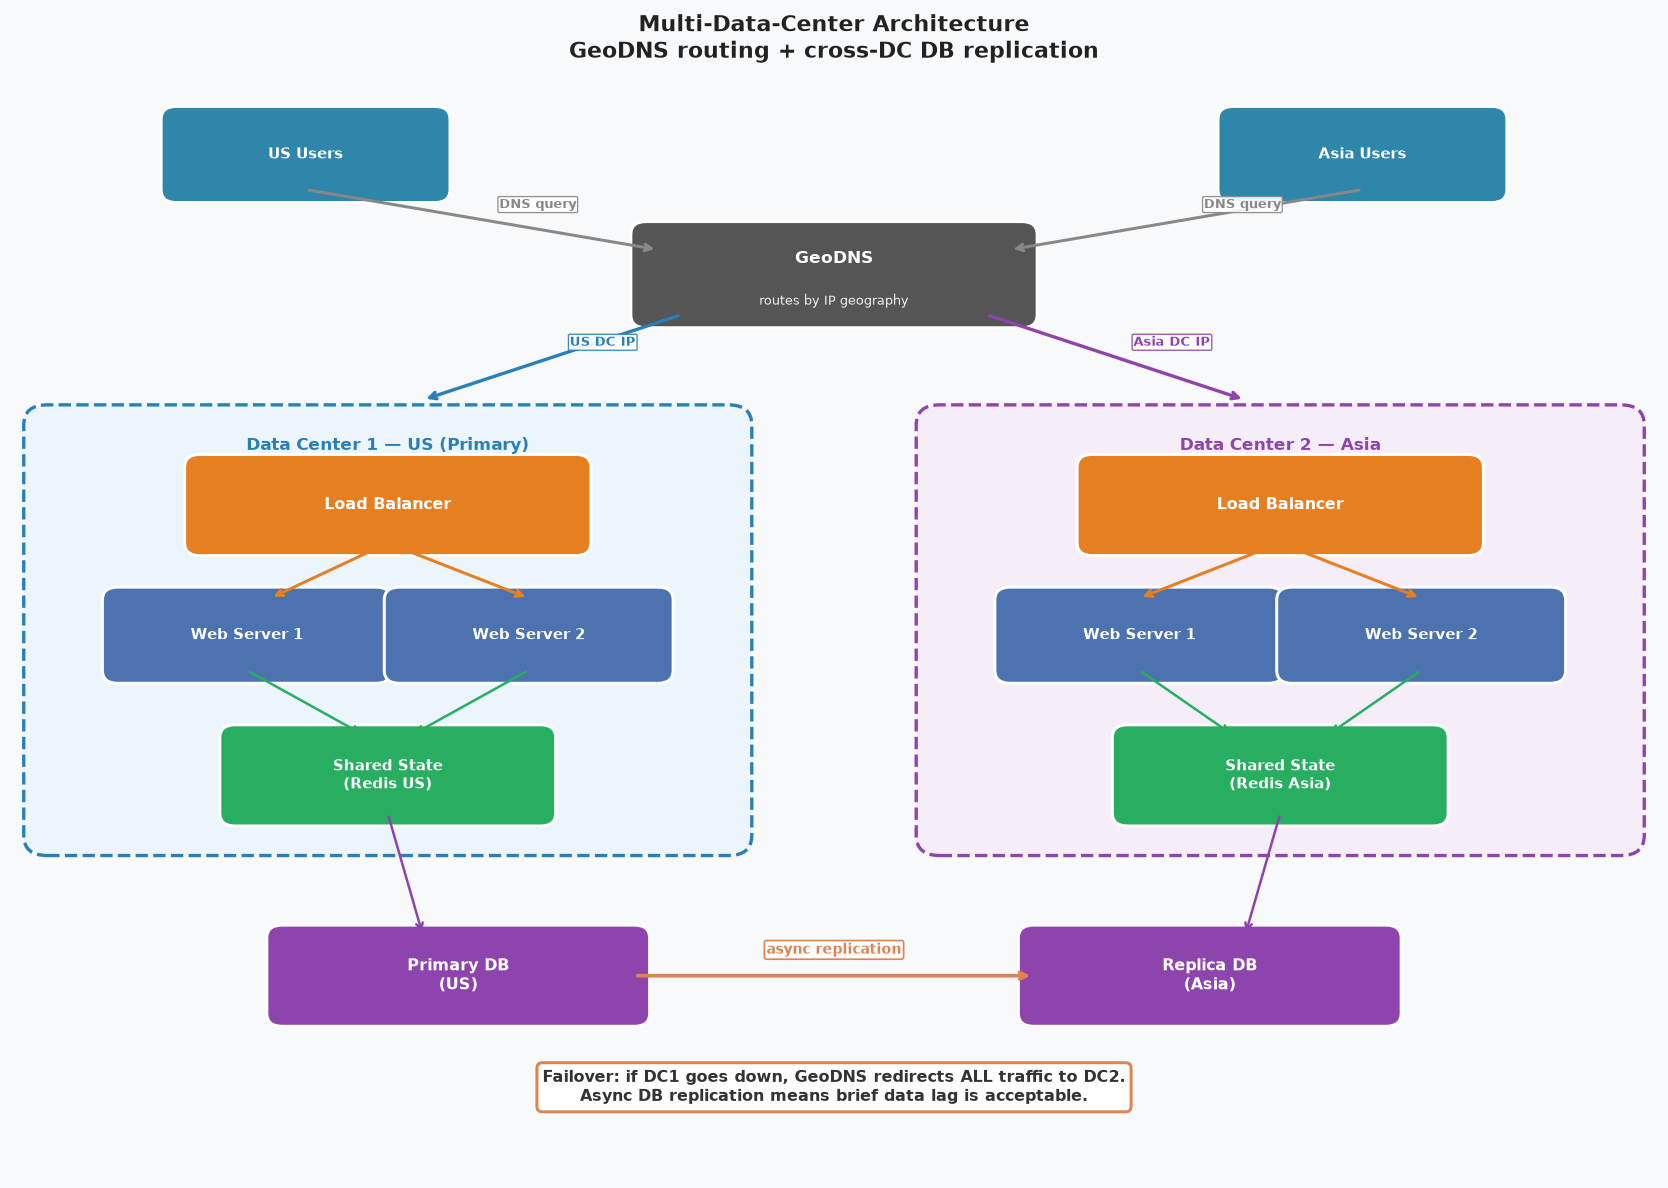

Multi-DC diagram done.


In [6]:
# Multi-data-center architecture: two DCs, GeoDNS routing, failover

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#EAF4FB')
fig.patch.set_facecolor(C_GRAY)

def box(ax, x, y, w, h, label, color, sub='', fs=9.5):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.13',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color='white')
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.9)

def arr(ax, x1, y1, x2, y2, label, color, lw=2.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.15
        ax.text(mx, my, label, ha='left', va='center',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.8, alpha=0.9))

# ── Users ─────────────────────────────────────────────────────────────────────
box(ax, 2.5, 10.2, 2.2, 0.7, 'US Users', C_USER, fs=9)
box(ax, 11.5,10.2, 2.2, 0.7, 'Asia Users', C_USER, fs=9)

# ── GeoDNS ────────────────────────────────────────────────────────────────────
box(ax, 7.0, 9.0, 3.2, 0.8, 'GeoDNS', '#555',
    sub='routes by IP geography', fs=10)
arr(ax, 2.5, 9.85,  5.5, 9.25, 'DNS query', '#888', lw=1.8)
arr(ax, 11.5, 9.85, 8.5, 9.25, 'DNS query', '#888', lw=1.8)
arr(ax, 5.7, 8.6,   3.5, 7.75, 'US DC IP', C_DC1, lw=2.0)
arr(ax, 8.3, 8.6,  10.5, 7.75, 'Asia DC IP', C_DC2, lw=2.0)

# ── Data Center 1: US ─────────────────────────────────────────────────────────
dc1_bg = FancyBboxPatch((0.3, 3.4), 5.8, 4.1,
                        boxstyle='round,pad=0.2',
                        facecolor='#EBF5FB', edgecolor=C_DC1, lw=2.0,
                        linestyle='--')
ax.add_patch(dc1_bg)
ax.text(3.2, 7.25, 'Data Center 1 — US (Primary)', ha='center',
        fontsize=10, fontweight='bold', color=C_DC1)

box(ax, 3.2, 6.7, 3.2, 0.75, 'Load Balancer', C_LB, fs=9.5)
box(ax, 2.0, 5.4, 2.2, 0.7,  'Web Server 1', C_SERVER, fs=9)
box(ax, 4.4, 5.4, 2.2, 0.7,  'Web Server 2', C_SERVER, fs=9)
box(ax, 3.2, 4.0, 2.6, 0.75, 'Shared State\n(Redis US)', C_SHARED, fs=9)

arr(ax, 3.2, 6.32, 2.2, 5.77, '', C_LB, lw=1.8)
arr(ax, 3.2, 6.32, 4.4, 5.77, '', C_LB, lw=1.8)
arr(ax, 2.0, 5.05, 3.0, 4.40, '', C_SHARED, lw=1.5)
arr(ax, 4.4, 5.05, 3.4, 4.40, '', C_SHARED, lw=1.5)

# ── Data Center 2: Asia ───────────────────────────────────────────────────────
dc2_bg = FancyBboxPatch((7.9, 3.4), 5.8, 4.1,
                        boxstyle='round,pad=0.2',
                        facecolor='#F5EEF8', edgecolor=C_DC2, lw=2.0,
                        linestyle='--')
ax.add_patch(dc2_bg)
ax.text(10.8, 7.25, 'Data Center 2 — Asia', ha='center',
        fontsize=10, fontweight='bold', color=C_DC2)

box(ax, 10.8, 6.7, 3.2, 0.75, 'Load Balancer', C_LB, fs=9.5)
box(ax, 9.6,  5.4, 2.2, 0.7,  'Web Server 1', C_SERVER, fs=9)
box(ax, 12.0, 5.4, 2.2, 0.7,  'Web Server 2', C_SERVER, fs=9)
box(ax, 10.8, 4.0, 2.6, 0.75, 'Shared State\n(Redis Asia)', C_SHARED, fs=9)

arr(ax, 10.8, 6.32,  9.6, 5.77, '', C_LB, lw=1.8)
arr(ax, 10.8, 6.32, 12.0, 5.77, '', C_LB, lw=1.8)
arr(ax,  9.6, 5.05, 10.4, 4.40, '', C_SHARED, lw=1.5)
arr(ax, 12.0, 5.05, 11.2, 4.40, '', C_SHARED, lw=1.5)

# ── DB Replication between DCs ────────────────────────────────────────────────
box(ax, 3.8, 2.0, 3.0, 0.75, 'Primary DB\n(US)', C_DB, fs=9.5)
box(ax, 10.2,2.0, 3.0, 0.75, 'Replica DB\n(Asia)', C_DB, fs=9.5)

arr(ax, 3.2, 3.62, 3.5, 2.40, '', C_DB, lw=1.5)
arr(ax, 10.8, 3.62, 10.5, 2.40, '', C_DB, lw=1.5)
# Cross-DC replication
ax.annotate('', xy=(8.7, 2.0), xytext=(5.3, 2.0),
            arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=2.2))
ax.text(7.0, 2.22, 'async replication', ha='center', fontsize=8.5,
        color=C_ORANGE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.0))

# ── Failover annotation ────────────────────────────────────────────────────────
ax.text(7.0, 0.75,
        'Failover: if DC1 goes down, GeoDNS redirects ALL traffic to DC2.\n'
        'Async DB replication means brief data lag is acceptable.',
        ha='center', fontsize=9.5, color='#333', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_ORANGE, lw=1.8))

ax.set_title('Multi-Data-Center Architecture\nGeoDNS routing + cross-DC DB replication',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_multi_dc.png', dpi=130, bbox_inches='tight')
plt.show()
print("Multi-DC diagram done.")


### What this shows

Two complete data centers — each with its own load balancer, two web servers, a Redis shared state store, and a database node.

**GeoDNS (centre top):** US users receive DC1's IP; Asia users receive DC2's IP. The DNS resolution itself is the routing decision — no application-layer logic needed.

**Dashed borders:** Each DC is an isolated network boundary (VPC). Blue border = US DC1 (primary), purple border = Asia DC2.

**Orange horizontal arrow:** Async replication from the primary DB (US) to the replica (Asia). Writes go to the primary; reads can be served from either. The replication lag (typically 10–100 ms across continents) means Asia users may read data that is slightly behind the primary — acceptable for most applications.

## 7. Multi-DC: Latency, Failover & Challenges

Multi-DC is not purely beneficial — it adds significant operational complexity.

**The three hardest problems:**
1. **Data consistency:** Async replication means Asia can read stale data written seconds ago in US. For financial transactions, this is unacceptable — those writes must go to primary only.
2. **Deployment synchronisation:** A code deploy must reach all DCs atomically to avoid version skew where DC1 and DC2 run different behaviour simultaneously.
3. **Data residency:** GDPR requires that EU user data stays in EU data centers. Your routing and storage logic must enforce this.

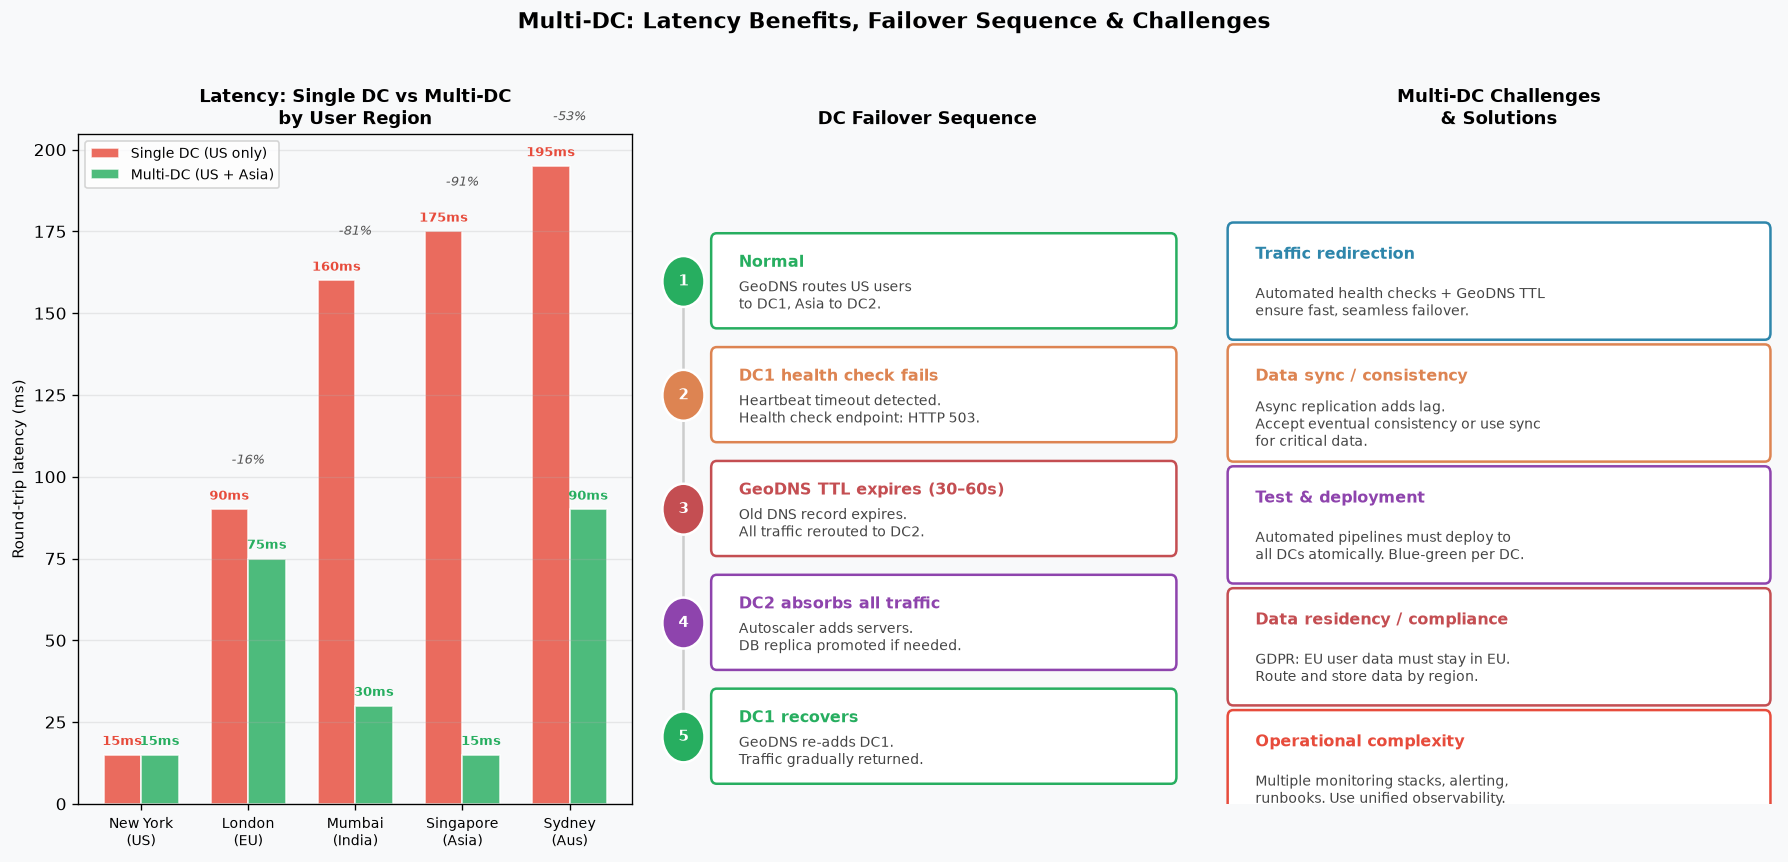

In [7]:
# Multi-DC: latency by region + failover scenarios + challenges

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

# ── Left: latency with single DC vs multi-DC ─────────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)

regions = ['New York\n(US)', 'London\n(EU)', 'Mumbai\n(India)',
           'Singapore\n(Asia)', 'Sydney\n(Aus)']
latency_1dc   = [15, 90, 160, 175, 195]   # ms  all go to US origin
latency_2dc   = [15, 75,  30,  15,  90]   # ms  US users -> US DC, Asia users -> Asia DC

x = np.arange(len(regions)); w = 0.35
bars1 = ax.bar(x - w/2, latency_1dc, width=w, color=C_SESSION, alpha=0.82,
               edgecolor='white', label='Single DC (US only)')
bars2 = ax.bar(x + w/2, latency_2dc, width=w, color=C_SHARED,  alpha=0.82,
               edgecolor='white', label='Multi-DC (US + Asia)')

ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8.5)
ax.set_ylabel('Round-trip latency (ms)', fontsize=9)
ax.set_title('Latency: Single DC vs Multi-DC\nby User Region', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.25)

for b1, b2 in zip(bars1, bars2):
    reduction = int((1 - b2.get_height() / b1.get_height()) * 100)
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 3,
            f'{b1.get_height()}ms', ha='center', fontsize=7.5,
            color=C_SESSION, fontweight='bold')
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 3,
            f'{b2.get_height()}ms', ha='center', fontsize=7.5,
            color=C_SHARED, fontweight='bold')
    if reduction > 0:
        ax.text(x[list(bars1).index(b1)], b1.get_height() + 14,
                f'-{reduction}%', ha='center', fontsize=7.5,
                color='#555', fontstyle='italic')

# ── Middle: failover simulation ───────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('DC Failover Sequence', fontsize=11, fontweight='bold')

failover_steps = [
    ('Normal',
     'GeoDNS routes US users\nto DC1, Asia to DC2.',
     C_GREEN),
    ('DC1 health check fails',
     'Heartbeat timeout detected.\nHealth check endpoint: HTTP 503.',
     C_ORANGE),
    ('GeoDNS TTL expires (30–60s)',
     'Old DNS record expires.\nAll traffic rerouted to DC2.',
     C_RED),
    ('DC2 absorbs all traffic',
     'Autoscaler adds servers.\nDB replica promoted if needed.',
     C_DC2),
    ('DC1 recovers',
     'GeoDNS re-adds DC1.\nTraffic gradually returned.',
     C_GREEN),
]

y0 = 9.5
for i, (title, body, color) in enumerate(failover_steps):
    y0 -= 1.7
    circ = plt.Circle((0.6, y0), 0.38, facecolor=color, edgecolor='white', lw=1.5)
    ax.add_patch(circ)
    ax.text(0.6, y0, str(i+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    r = FancyBboxPatch((1.2, y0 - 0.6), 8.2, 1.22,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(1.6, y0 + 0.28, title, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(1.6, y0 - 0.22, body, ha='left', va='center',
            fontsize=8.5, color='#444')
    if i < 4:
        ax.plot([0.6, 0.6], [y0 - 0.4, y0 - 1.3], color='#CCC', lw=1.5, zorder=0)

# ── Right: multi-DC challenges ────────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Multi-DC Challenges\n& Solutions', fontsize=11, fontweight='bold')

challenges = [
    ('Traffic redirection',
     'Automated health checks + GeoDNS TTL\nensure fast, seamless failover.',
     C_TEAL),
    ('Data sync / consistency',
     'Async replication adds lag.\nAccept eventual consistency or use sync\nfor critical data.',
     C_ORANGE),
    ('Test & deployment',
     'Automated pipelines must deploy to\nall DCs atomically. Blue-green per DC.',
     C_DC2),
    ('Data residency / compliance',
     'GDPR: EU user data must stay in EU.\nRoute and store data by region.',
     C_RED),
    ('Operational complexity',
     'Multiple monitoring stacks, alerting,\nrunbooks. Use unified observability.',
     C_SESSION),
]

y0 = 9.6
for (challenge, solution, color) in challenges:
    y0 -= 1.82
    r = FancyBboxPatch((0.2, y0 - 0.75), 9.6, 1.55,
                       boxstyle='round,pad=0.1',
                       facecolor='white', edgecolor=color, lw=1.5)
    ax.add_patch(r)
    ax.text(0.6, y0 + 0.42, challenge, ha='left', va='center',
            fontsize=9.5, fontweight='bold', color=color)
    ax.text(0.6, y0 - 0.3, solution, ha='left', va='center',
            fontsize=8.5, color='#444')

plt.suptitle('Multi-DC: Latency Benefits, Failover Sequence & Challenges',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_dc_details.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Latency by region:**  
Adding an Asia DC cuts latency for Mumbai (160ms → 30ms) and Singapore (175ms → 15ms) by over 80%. London improves moderately (90ms → 75ms — still routes to US, a third EU DC would fix this). The US experience is unchanged.

**Middle — Failover sequence:**  
Five ordered steps from normal operation through DC1 failure and recovery. The critical delay is the GeoDNS TTL (30–60 seconds) — the period during which some clients still resolve to the failed DC's IP. Shorter TTLs improve failover speed but increase DNS lookup overhead.

**Right — Challenges & solutions:**  
Five challenges (traffic redirection, data sync, testing/deployment, data residency, operational complexity) each with a practical mitigation strategy. These are the real engineering costs of going multi-region.

## 8. Architecture Evolution & Scorecard

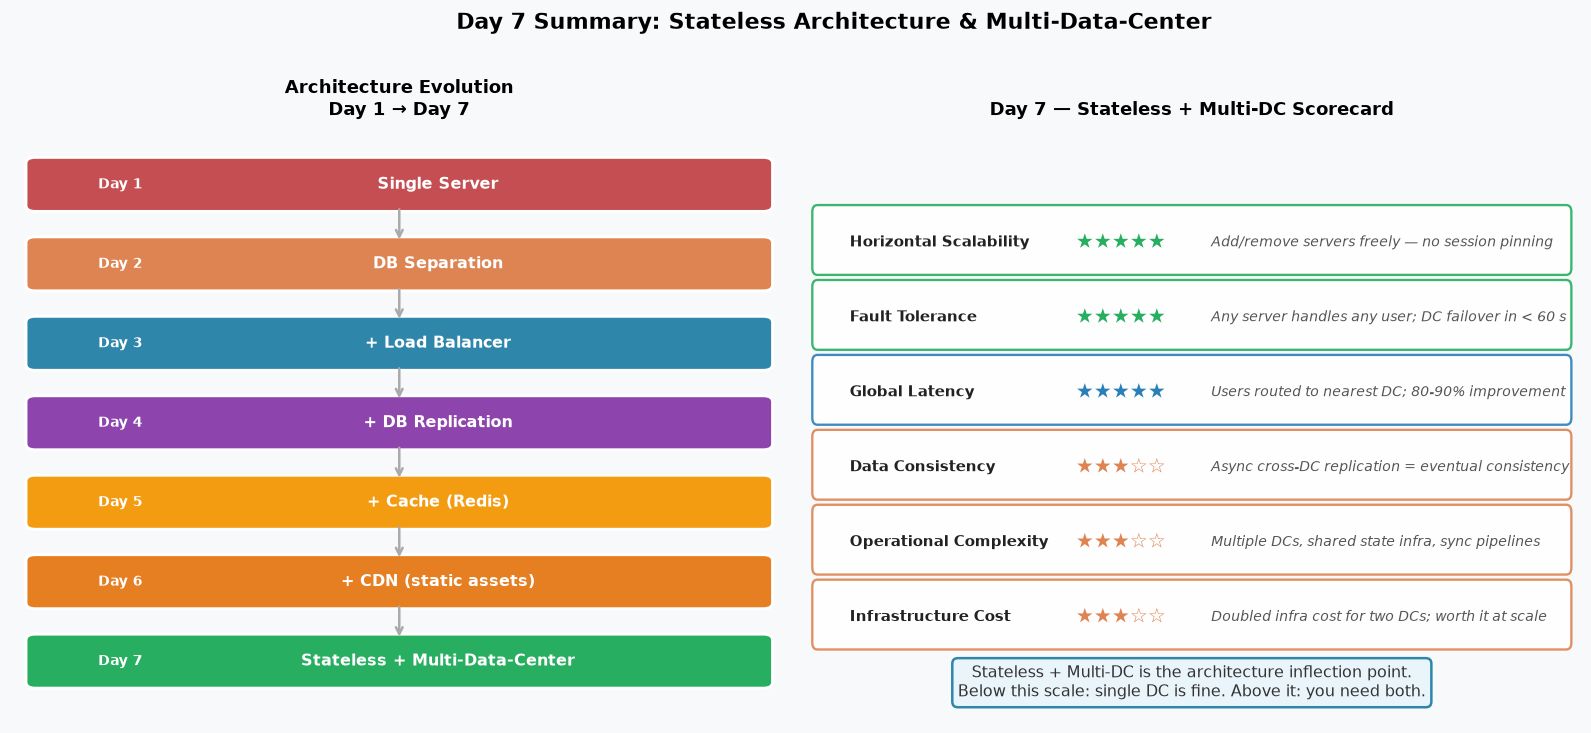

Day 7 complete.


In [8]:
# Day 7 Scorecard + Evolution Day 1 -> 7

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 7', fontsize=11, fontweight='bold')

days = [
    ('Day 1', 'Single Server',                     C_RED),
    ('Day 2', 'DB Separation',                     C_ORANGE),
    ('Day 3', '+ Load Balancer',                   C_TEAL),
    ('Day 4', '+ DB Replication',                  '#8E44AD'),
    ('Day 5', '+ Cache (Redis)',                   '#F39C12'),
    ('Day 6', '+ CDN (static assets)',             '#E67E22'),
    ('Day 7', 'Stateless + Multi-Data-Center',     C_SHARED),
]
ys = np.linspace(10.8, 1.2, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 7 — Stateless + Multi-DC Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('Horizontal Scalability', '★★★★★', C_SHARED,
     'Add/remove servers freely — no session pinning'),
    ('Fault Tolerance',        '★★★★★', C_SHARED,
     'Any server handles any user; DC failover in < 60 s'),
    ('Global Latency',         '★★★★★', C_DC1,
     'Users routed to nearest DC; 80-90% improvement'),
    ('Data Consistency',       '★★★☆☆', C_ORANGE,
     'Async cross-DC replication = eventual consistency'),
    ('Operational Complexity', '★★★☆☆', C_ORANGE,
     'Multiple DCs, shared state infra, sync pipelines'),
    ('Infrastructure Cost',    '★★★☆☆', C_ORANGE,
     'Doubled infra cost for two DCs; worth it at scale'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4, alpha=0.9)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.9,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.3,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Stateless + Multi-DC is the architecture inflection point.\n'
        'Below this scale: single DC is fine. Above it: you need both.',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.suptitle('Day 7 Summary: Stateless Architecture & Multi-Data-Center',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day7_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 7 complete.")


### What this shows

**Left — Evolution Day 1 → Day 7:**  
Day 7 completes the first major architecture milestone: the system is now stateless (any server handles any user), globally distributed (two DCs with GeoDNS), and resilient to single data-center failures.

**Right — Day 7 Scorecard:**
- **Horizontal Scalability (5/5):** Stateless web tier + shared store = freely elastic.
- **Fault Tolerance (5/5):** Server failure is seamless; DC failure recovers in < 60 s.
- **Global Latency (5/5):** GeoDNS + multiple DCs cuts latency 80%+ for distant users.
- **Data Consistency (3/5):** Async cross-DC replication introduces eventual consistency lag.
- **Operational Complexity (3/5):** Two DCs, shared state, sync deployments, monitoring stacks.
- **Infrastructure Cost (3/5):** Roughly double the infra for two DCs — justified at global scale.

**Key insight:** Stateless + multi-DC is the inflection point in the series. Days 1-6 optimise a single-region system. Day 7 takes it global.

## AWS Production Notes

> Based on the AWS Well-Architected Framework and AWS official documentation.

---

### Critical Corrections

| Claim in This Notebook | Correction |
|---|---|
| 'GeoDNS' presented as a single routing mechanism | Route 53 has **three distinct policies** with different behaviors: **Geolocation** (administrative geographic boundaries), **Latency-based** (real-time measurements), **Geoproximity** (bias parameter). Latency-based is typically recommended — geography does not always equal low latency. |
| 'Mumbai latency drops from 160ms to 30ms with US + Asia DC' | If Asia DC is ap-southeast-1 (Singapore), Mumbai → Singapore RTT is **60–80ms**, not 30ms. 30ms for Mumbai requires **ap-south-1 (Mumbai)** or **ap-south-2 (Hyderabad)**. |
| 'NoSQL preferred for state store because it scales horizontally' | For session caching, **Redis is preferred for microsecond latency**, DynamoDB for **durability and multi-region replication**. The framing should be based on latency/durability requirement, not 'NoSQL vs SQL'. |
| 'Cross-DC replication lag typically 10–100ms across continents' | Light-travel time alone US-East → ap-southeast-1 is ~90ms one-way (180ms RTT). Standard async replication lag is **100–300ms**. Aurora Global Database achieves sub-100ms via dedicated replication infrastructure — this is a premium managed service feature. |

---

### Multi-AZ First: The Cheaper Step This Day Skips

This day jumps to multi-DC before covering the foundational AWS HA pattern:

```
Step 1: Multi-AZ (SAME region, ~1ms between AZs)
  ALB in 2-3 AZs + EC2 ASG across AZs + RDS Multi-AZ + ElastiCache Multi-AZ
  → 99.99% availability; fraction of multi-region cost
  → Well-Architected REL04-BP01: 'Start with AZs'

Step 2: Multi-Region (only when Multi-AZ doesn't meet RTO/RPO)
  Aurora Global Database + DynamoDB Global Tables + Route 53 latency-based routing
  → 50-200ms between regions; additional data transfer costs ($0.02/GB)
```

---

### Route 53 Routing Policies Compared

| Policy | How It Routes | Best For |
|---|---|---|
| **Latency-based** | Real-time AWS latency measurements between user and region | General performance routing — **most commonly recommended** |
| **Geolocation** | Maps user's IP to administrative country/continent | Legal/compliance data residency, language-specific content |
| **Geoproximity** | Distance with a configurable bias (+/-) to shift traffic boundaries | Fine-tuning traffic split when Latency-based isn't precise enough |
| **Weighted** | Fixed percentage split (e.g. 70/30) | Blue/green deployments, canary rollouts |
| **Failover** | Active/passive with Health Check | DR failover to standby region |

---

### AWS Services for Cross-Region State (replaces generic async replication)

| Generic Pattern | AWS Service | Capability |
|---|---|---|
| Cross-region async replication (10–100ms) | **Aurora Global Database** | < 1s typical lag; up to 5 secondary regions; managed failover |
| Active-active session state | **DynamoDB Global Tables** | Multi-active across up to 20 regions; millisecond replication; any region accepts writes |
| Cross-region Redis | **ElastiCache Global Datastore** | Managed cross-region Valkey/Redis replication |

---

### Route 53 Health Checks: What Actually Detects Failure

The notebook says 'GeoDNS redirects all traffic to DC2 on failure' without explaining the detection mechanism:

- Route 53 evaluates endpoints **every 10 or 30 seconds** from **15 globally distributed health checkers**
- Even after Route 53 removes a DNS record, **clients that cached the old IP continue sending traffic until TTL expires**
- Recommended config: health check interval = 10s, failure threshold = 3, DNS TTL = 60s for failover records
- Use **AWS Global Accelerator** when DNS TTL-based failover (30–60s exposure window) is too slow

---

### Well-Architected Checklist

- [ ] **REL 4** — Deploy to multiple AZs within single region before adding multi-region (REL04-BP01)
- [ ] **REL 6** — Use Route 53 latency-based routing for performance-sensitive workloads
- [ ] **REL 9** — Aurora Global Database for cross-region relational data; DynamoDB Global Tables for active-active NoSQL
- [ ] **REL 13** — Test failover using AWS Fault Injection Simulator (FIS) regularly
- [ ] **SEC 5** — All state stores (Redis, DB) in private subnets; no cross-region traffic bypasses VPC
- [ ] **COST 4** — Account for cross-region data transfer costs ($0.02/GB for US regions)
